## Big Data & AI Bootcamp
### Machine Learning Track

### Desert Ninjas

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import OrdinalEncoder

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

## Importing the dataset

In [2]:
dataset = pd.read_csv("Combined_Flights_2022.csv")

dataset.head(10)

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,False,False,1133,1123.0,0.0,-10.0,...,1140.0,1220.0,8.0,1245,-17.0,0.0,-2.0,1200-1259,1,0
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,False,False,732,728.0,0.0,-4.0,...,744.0,839.0,9.0,849,-1.0,0.0,-1.0,0800-0859,2,0
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1529,1514.0,0.0,-15.0,...,1535.0,1622.0,14.0,1639,-3.0,0.0,-1.0,1600-1659,2,0
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,False,False,1435,1430.0,0.0,-5.0,...,1446.0,1543.0,4.0,1605,-18.0,0.0,-2.0,1600-1659,2,0
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1135,1135.0,0.0,0.0,...,1154.0,1243.0,8.0,1245,6.0,0.0,0.0,1200-1259,2,0
5,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DEN,TUL,False,False,955,952.0,0.0,-3.0,...,1017.0,1234.0,4.0,1240,-2.0,0.0,-1.0,1200-1259,3,0
6,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,LCH,False,False,2139,2136.0,0.0,-3.0,...,2147.0,2213.0,5.0,2231,-13.0,0.0,-1.0,2200-2259,1,0
7,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",TYS,IAH,False,False,1129,1117.0,0.0,-12.0,...,1139.0,1255.0,16.0,1306,5.0,0.0,0.0,1300-1359,4,0
8,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,AEX,False,False,1424,1414.0,0.0,-10.0,...,1430.0,1507.0,6.0,1524,-11.0,0.0,-1.0,1500-1559,1,0
9,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,MOB,False,False,954,947.0,0.0,-7.0,...,1004.0,1104.0,6.0,1121,-11.0,0.0,-1.0,1100-1159,2,0


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4078318 entries, 0 to 4078317
Data columns (total 61 columns):
 #   Column                                   Dtype  
---  ------                                   -----  
 0   FlightDate                               object 
 1   Airline                                  object 
 2   Origin                                   object 
 3   Dest                                     object 
 4   Cancelled                                bool   
 5   Diverted                                 bool   
 6   CRSDepTime                               int64  
 7   DepTime                                  float64
 8   DepDelayMinutes                          float64
 9   DepDelay                                 float64
 10  ArrTime                                  float64
 11  ArrDelayMinutes                          float64
 12  AirTime                                  float64
 13  CRSElapsedTime                           float64
 14  ActualElapsedTime 

In [8]:
dataset.describe()

,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,...,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,DistanceGroup,DivAirportLandings
count,4.078318e+06,3.957885e+06,3.957823e+06,3.957823e+06,3.954079e+06,3.944916e+06,3.944916e+06,4.078318e+06,3.944916e+06,4.078318e+06,...,3.955652e+06,3.955652e+06,3.954076e+06,3.954076e+06,4.078318e+06,3.944916e+06,3.944916e+06,3.944916e+06,4.078318e+06,4.078318e+06
mean,1.329587e+03,1.334374e+03,1.601494e+01,1.309049e+01,1.457886e+03,1.578307e+01,1.110075e+02,1.413211e+02,1.358624e+02,7.978657e+02,...,1.697375e+01,1.356576e+03,1.455073e+03,7.894387e+00,1.486058e+03,7.528486e+00,2.164715e-01,-6.256103e-02,3.663516e+00,3.685098e-03
std,4.904801e+02,5.056219e+02,5.231498e+01,5.332016e+01,5.431841e+02,5.198424e+01,6.996246e+01,7.179635e+01,7.185501e+01,5.914742e+02,...,9.495407e+00,5.075580e+02,5.378428e+02,6.663118e+00,5.185078e+02,5.524625e+01,4.118393e-01,2.487442e+00,2.320848e+00,1.141331e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,-7.800000e+01,1.000000e+00,0.000000e+00,8.000000e+00,-4.800000e+01,1.400000e+01,3.100000e+01,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.000000e+02,0.000000e+00,-2.000000e+00,1.000000e+00,0.000000e+00
25%,9.140000e+02,9.170000e+02,0.000000e+00,-5.000000e+00,1.046000e+03,0.000000e+00,6.000000e+01,8.900000e+01,8.300000e+01,3.680000e+02,...,1.100000e+01,9.320000e+02,1.044000e+03,4.000000e+00,1.103000e+03,-1.400000e+01,0.000000e+00,-1.000000e+00,2.000000e+00,0.000000e+00
50%,1.320000e+03,1.325000e+03,0.000000e+00,-2.000000e+00,1.500000e+03,0.000000e+00,9.400000e+01,1.240000e+02,1.190000e+02,6.430000e+02,...,1.500000e+01,1.338000e+03,1.456000e+03,6.000000e+00,1.513000e+03,-5.000000e+00,0.000000e+00,-1.000000e+00,3.000000e+00,0.000000e+00
75%,1.735000e+03,1.744000e+03,1.100000e+01,1.100000e+01,1.914000e+03,1.000000e+01,1.410000e+02,1.710000e+02,1.670000e+02,1.035000e+03,...,1.900000e+01,1.758000e+03,1.909000e+03,9.000000e+00,1.920000e+03,1.000000e+01,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00
max,2.359000e+03,2.400000e+03,7.223000e+03,7.223000e+03,2.400000e+03,7.232000e+03,7.270000e+02,6.900000e+02,7.640000e+02,5.095000e+03,...,2.210000e+02,2.400000e+03,2.400000e+03,2.900000e+02,2.359000e+03,7.232000e+03,1.000000e+00,1.200000e+01,1.100000e+01,9.000000e+00


## EDA

In [9]:
# Split the delay minutes into four categories 
dataset["DelayGroup"] = None
dataset.loc[dataset["DepDelayMinutes"] == 0, "DelayGroup"] = "OnTime_Early"
dataset.loc[(dataset["DepDelayMinutes"] > 0) & (dataset["DepDelayMinutes"] <= 15), "DelayGroup"] = "Small_Delay"
dataset.loc[(dataset["DepDelayMinutes"] > 15) & (dataset["DepDelayMinutes"] <= 45), "DelayGroup"] = "Medium_Delay"
dataset.loc[dataset["DepDelayMinutes"] > 45, "DelayGroup"] = "Large_Delay"
dataset.loc[dataset["Cancelled"], "DelayGroup"] = "Cancelled"

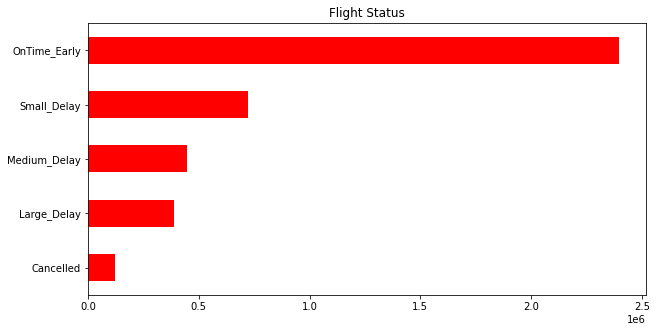

In [10]:
dataset["DelayGroup"].value_counts(ascending=True).plot(
    kind="barh", figsize=(10, 5), color='red', title="Flight Status")
plt.show()

Text(0.5, 0, 'Number of Flights')

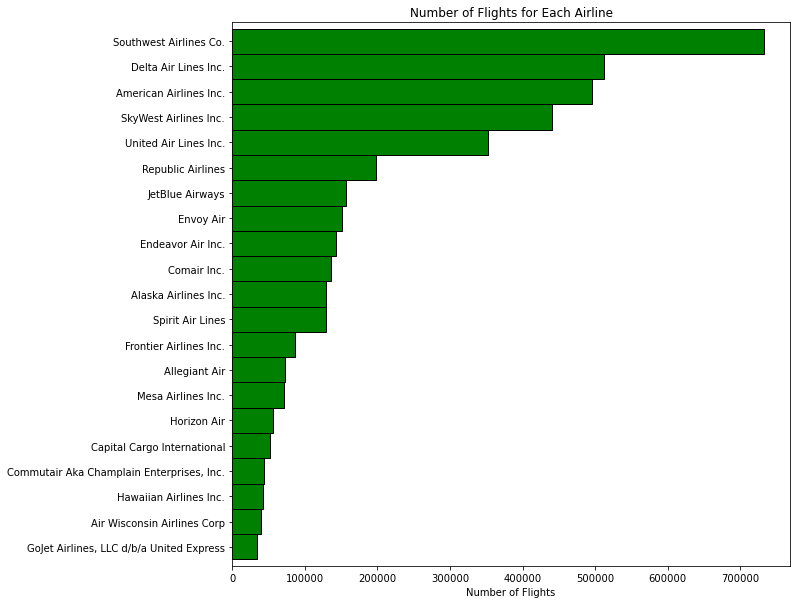

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
airlines_ordered = (dataset["Airline"].value_counts(ascending=True)).plot(kind="barh", color="green", ax=ax, 
                                                                     width=1, edgecolor="black")
ax.set_title("Number of Flights for Each Airline")
ax.set_xlabel("Number of Flights")

In [12]:
top_airlines = (
    dataset["Airline"]
    .value_counts()
    .reset_index()
    .query("Airline > 1_000_000")["index"]
    .values.tolist())

df_top = dataset.loc[dataset["Airline"].isin(top_airlines)].reset_index(drop=True).copy()

In [13]:
# Reset airline categories
df_top["Airline"] = df_top["Airline"].astype("str").astype("category")

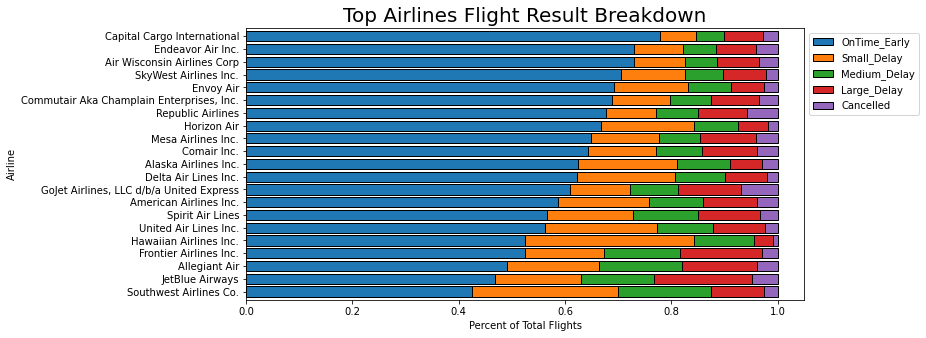

In [14]:
col_order = ["OnTime_Early", "Small_Delay", "Medium_Delay", "Large_Delay", "Cancelled"]
df_agg = ( dataset.groupby(["Airline"])["DelayGroup"].value_counts(normalize=True).unstack()[col_order])
fig, ax = plt.subplots(figsize=(10, 5))
df_agg.sort_values("OnTime_Early").plot(kind="barh", stacked=True, ax=ax, width=0.8, edgecolor="black")
ax.legend(bbox_to_anchor=(1, 1))
ax.set_title("Top Airlines Flight Result Breakdown", fontsize=20)
ax.set_xlabel("Percent of Total Flights")
plt.show()

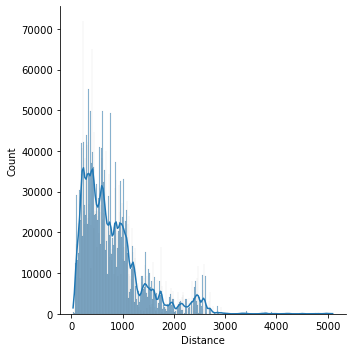

In [15]:
sns.displot(data=dataset, x="Distance", kde=True)

##### The rest of the charts is in the dashboard.

# Classification

In [16]:
df = dataset[["CRSDepTime", 'WheelsOff','WheelsOn','Distance','DistanceGroup', "TaxiOut", "TaxiIn", "ArrDelayMinutes"]].copy()

In [17]:
df.isnull().sum()

CRSDepTime              0
WheelsOff          122666
WheelsOn           124242
Distance                0
DistanceGroup           0
TaxiOut            122666
TaxiIn             124242
ArrDelayMinutes    133402
dtype: int64

In [18]:
# Handling the columns missing values:

WheelsOff_mean = round(df['WheelsOff'].mean())
WheelsOn_mean = round(df['WheelsOn'].mean())
TaxiOut_mean = round(df['TaxiOut'].mean())
TaxiIn_mean = round(df['TaxiIn'].mean())

In [19]:
# Replace NaN values with the mean:
df["WheelsOff"].fillna(WheelsOff_mean, inplace=True)
df["WheelsOn"].fillna(WheelsOn_mean, inplace=True)
df["TaxiOut"].fillna(TaxiOut_mean, inplace=True)
df["TaxiIn"].fillna(TaxiIn_mean, inplace=True)

df.isnull().sum()

CRSDepTime              0
WheelsOff               0
WheelsOn                0
Distance                0
DistanceGroup           0
TaxiOut                 0
TaxiIn                  0
ArrDelayMinutes    133402
dtype: int64

In [20]:
df = df[df['ArrDelayMinutes'].notna()]

In [21]:
df.isnull().sum()

CRSDepTime         0
WheelsOff          0
WheelsOn           0
Distance           0
DistanceGroup      0
TaxiOut            0
TaxiIn             0
ArrDelayMinutes    0
dtype: int64

In [22]:
df

,CRSDepTime,WheelsOff,WheelsOn,Distance,DistanceGroup,TaxiOut,TaxiIn,ArrDelayMinutes
0,1133,1140.0,1220.0,212.0,1,17.0,8.0,0.0
1,732,744.0,839.0,295.0,2,16.0,9.0,0.0
2,1529,1535.0,1622.0,251.0,2,21.0,14.0,0.0
3,1435,1446.0,1543.0,376.0,2,16.0,4.0,0.0
4,1135,1154.0,1243.0,251.0,2,19.0,8.0,6.0
...,...,...,...,...,...,...,...,...
4078308,1617,2012.0,2244.0,1196.0,5,19.0,12.0,207.0
4078309,1418,1815.0,1920.0,404.0,2,14.0,10.0,201.0
4078310,1750,2119.0,2156.0,182.0,1,14.0,5.0,180.0
4078312,2035,2323.0,47.0,946.0,4,14.0,5.0,135.0


## Binning Continous Variable into Categorical

In [23]:
# creating a new coulmn that Bin a continuous variable (ArrDelayMinutes into catigorical ), 


# Set On Time and Delay Groupings
Delays_1 = []
for row in df['ArrDelayMinutes']:
        if row == 0: Delays_1.append('NoDelay')
        elif row > 0: Delays_1.append('Delay')

In [24]:
df['Delays_1'] = Delays_1

In [25]:
#ordinal encoder

df['Delays_1'].replace(['NoDelay', "Delay"], [0, 1], inplace=True)

In [26]:
#sns.pairplot(df)

In [27]:
#run again 
# Weak Correlation --> below 0.5 
# Correlation --> 0.5 - 0.7
# Strong Correlation --> more than 0.7

corr = df.corr()

corr.style.background_gradient(cmap='coolwarm')

,CRSDepTime,WheelsOff,WheelsOn,Distance,DistanceGroup,TaxiOut,TaxiIn,ArrDelayMinutes,Delays_1
CRSDepTime,1.000000,0.915205,0.607646,-0.003080,-0.004222,-0.001088,-0.020917,0.085159,0.152544
WheelsOff,0.915205,1.000000,0.662889,-0.026851,-0.028164,0.033848,-0.017594,0.101742,0.185342
WheelsOn,0.607646,0.662889,1.000000,0.011854,0.015202,0.026243,0.010067,0.019002,0.100206
Distance,-0.003080,-0.026851,0.011854,1.000000,0.986306,0.029303,0.068712,0.010952,0.030982
DistanceGroup,-0.004222,-0.028164,0.015202,0.986306,1.000000,0.028021,0.067311,0.011450,0.031536
TaxiOut,-0.001088,0.033848,0.026243,0.029303,0.028021,1.000000,0.015994,0.149370,0.255892
TaxiIn,-0.020917,-0.017594,0.010067,0.068712,0.067311,0.015994,1.000000,0.087745,0.158698
ArrDelayMinutes,0.085159,0.101742,0.019002,0.010952,0.011450,0.149370,0.087745,1.000000,0.389768
Delays_1,0.152544,0.185342,0.100206,0.030982,0.031536,0.255892,0.158698,0.389768,1.000000


ArrDelayMinutes, TaxiOut, WheelsOff, CRSDepTime

In [28]:
df.shape

(3944916, 9)

In [29]:
df.Delays_1.value_counts(normalize=True)

# Baseline --> is Zero --> would be accurate by 257/400 = 64%
# Whenever I build a model it needs to be more accurate than 64% 


0    0.622365
1    0.377635
Name: Delays_1, dtype: float64

In [30]:
df

,CRSDepTime,WheelsOff,WheelsOn,Distance,DistanceGroup,TaxiOut,TaxiIn,ArrDelayMinutes,Delays_1
0,1133,1140.0,1220.0,212.0,1,17.0,8.0,0.0,0
1,732,744.0,839.0,295.0,2,16.0,9.0,0.0,0
2,1529,1535.0,1622.0,251.0,2,21.0,14.0,0.0,0
3,1435,1446.0,1543.0,376.0,2,16.0,4.0,0.0,0
4,1135,1154.0,1243.0,251.0,2,19.0,8.0,6.0,1
...,...,...,...,...,...,...,...,...,...
4078308,1617,2012.0,2244.0,1196.0,5,19.0,12.0,207.0,1
4078309,1418,1815.0,1920.0,404.0,2,14.0,10.0,201.0,1
4078310,1750,2119.0,2156.0,182.0,1,14.0,5.0,180.0,1
4078312,2035,2323.0,47.0,946.0,4,14.0,5.0,135.0,1


## Splitting the dataset into the Training set and Test set

In [31]:
# feature set --> one or more than one column 
X = df.iloc[:, 0:8 ] 

# target set --> one column
y = df.iloc[:, -1]

# feature set and the target for both the training and the testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [32]:
X.head()

,CRSDepTime,WheelsOff,WheelsOn,Distance,DistanceGroup,TaxiOut,TaxiIn,ArrDelayMinutes
0,1133,1140.0,1220.0,212.0,1,17.0,8.0,0.0
1,732,744.0,839.0,295.0,2,16.0,9.0,0.0
2,1529,1535.0,1622.0,251.0,2,21.0,14.0,0.0
3,1435,1446.0,1543.0,376.0,2,16.0,4.0,0.0
4,1135,1154.0,1243.0,251.0,2,19.0,8.0,6.0


In [33]:
y.head()

0    0
1    0
2    0
3    0
4    1
Name: Delays_1, dtype: int64

## Feature Scaling

In [34]:
#to make sure that all features are equally important 

sc = StandardScaler()

# Note: We are scaling all the variables "Age and Salary" for improved performance 
# Note: we only scale continous numneric variables --> DONT scale discrete numbers 
# The scaling will be between 3 and -3 

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training the Logistic Regression model on the Training set

[Scikit-learn Documentation: Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)

In [35]:
classifier = LogisticRegression(random_state = 42)

classifier.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [36]:
classifier.score(X_test, y_test)

0.9999878324405387

## Predicting the Test set results

In [37]:
y_pred = classifier.predict(X_test)

print(y_pred)

[0 1 1 ... 0 1 1]


/Users/johara/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


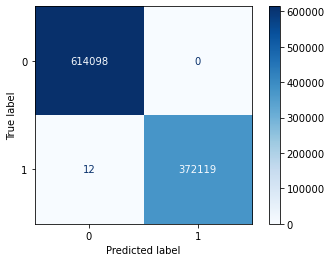

In [38]:
plot_confusion_matrix(classifier, X=X_test, y_true=y_test, cmap='Blues')

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    614098
           1       1.00      1.00      1.00    372131

    accuracy                           1.00    986229
   macro avg       1.00      1.00      1.00    986229
weighted avg       1.00      1.00      1.00    986229



# Regression

* Note: this viulization doesn't work on this laptop so we copied it

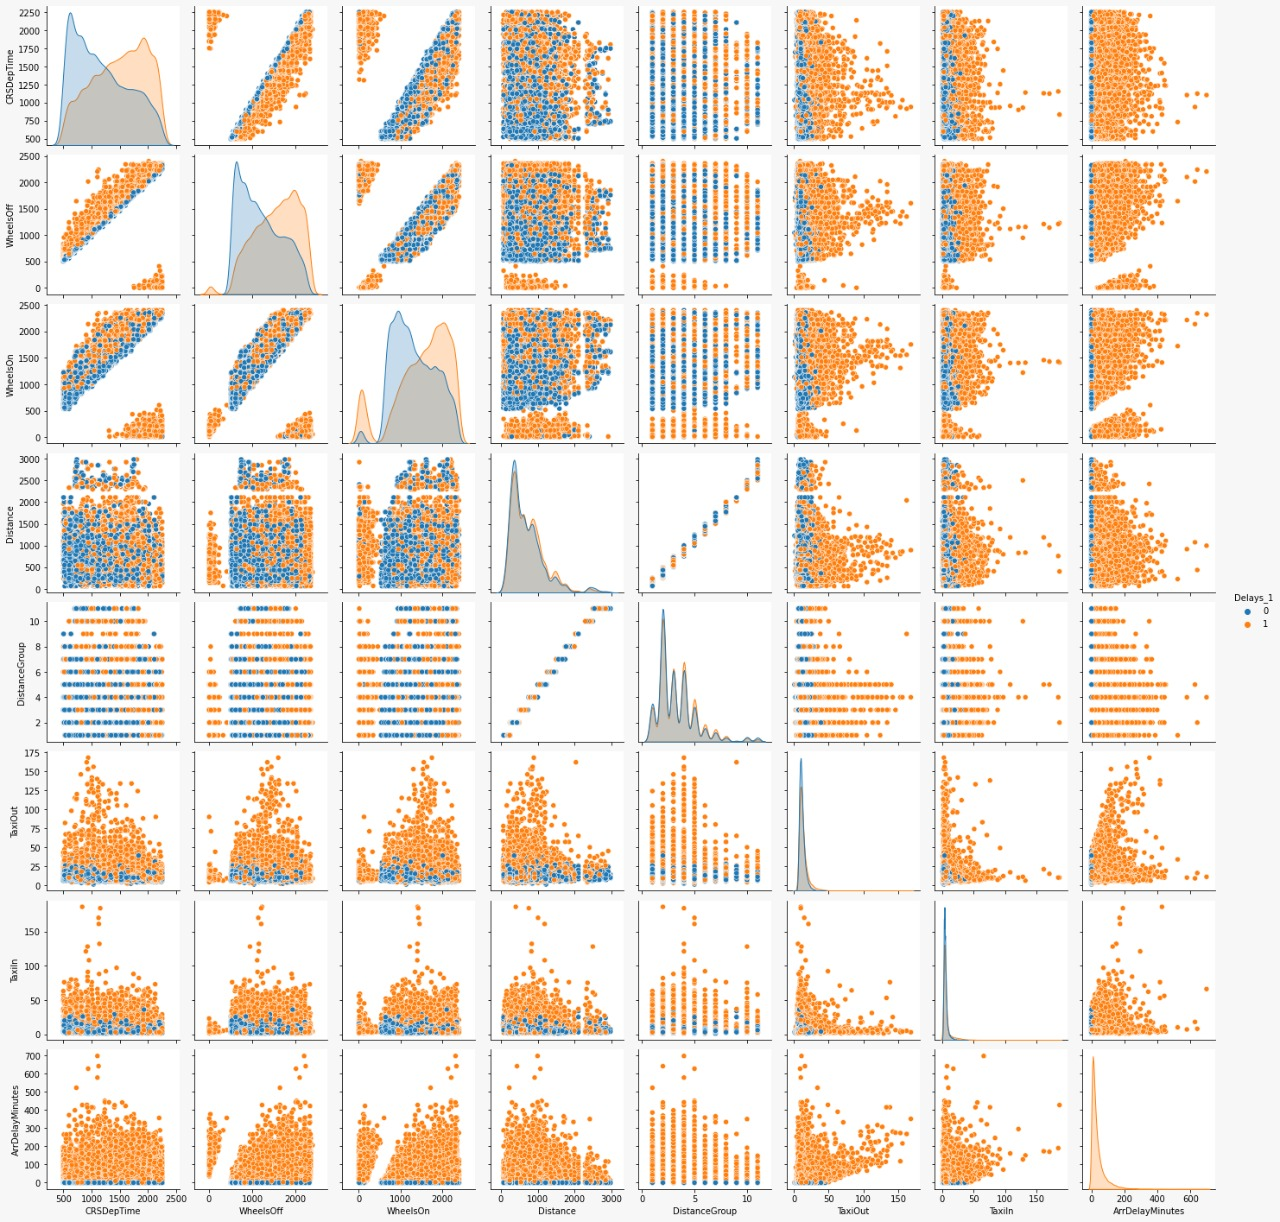

CRSDepTime X WheelsOff (remove outliers)

CRS Departure Time (local time: hhmm)

Wheels Off Time (local time: hhmm)

### Linear regression


In [40]:
df_2 = dataset[["DivAirportLandings", "DepartureDelayGroups", "DepDel15", "DepDelay", "DepDelayMinutes", "Diverted"
                ,"CRSDepTime", "WheelsOff","WheelsOn",
              "Distance", "ArrDelayMinutes", "DistanceGroup"]].copy()

In [41]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4078318 entries, 0 to 4078317
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   DivAirportLandings    int64  
 1   DepartureDelayGroups  float64
 2   DepDel15              float64
 3   DepDelay              float64
 4   DepDelayMinutes       float64
 5   Diverted              bool   
 6   CRSDepTime            int64  
 7   WheelsOff             float64
 8   WheelsOn              float64
 9   Distance              float64
 10  ArrDelayMinutes       float64
 11  DistanceGroup         int64  
dtypes: bool(1), float64(8), int64(3)
memory usage: 346.2 MB


In [42]:
train, test = train_test_split(
    df_2,
    test_size=0.25,
    random_state = 42
)

In [43]:
train.head()

,DivAirportLandings,DepartureDelayGroups,DepDel15,DepDelay,DepDelayMinutes,Diverted,CRSDepTime,WheelsOff,WheelsOn,Distance,ArrDelayMinutes,DistanceGroup
489475,0,-1.0,0.0,-10.0,0.0,False,1310,1331.0,1429.0,284.0,7.0,2
1478565,0,-1.0,0.0,-1.0,0.0,False,845,912.0,1615.0,1849.0,19.0,8
2296125,0,-1.0,0.0,-8.0,0.0,False,1355,1355.0,1454.0,335.0,0.0,2
506611,0,0.0,0.0,12.0,12.0,False,1145,1213.0,1309.0,748.0,0.0,3
1446897,0,-1.0,0.0,-3.0,0.0,False,1530,1536.0,1812.0,733.0,0.0,3


In [44]:
test.head()

,DivAirportLandings,DepartureDelayGroups,DepDel15,DepDelay,DepDelayMinutes,Diverted,CRSDepTime,WheelsOff,WheelsOn,Distance,ArrDelayMinutes,DistanceGroup
3811797,0,-1.0,0.0,-5.0,0.0,False,1831,1845.0,1916.0,125.0,0.0,1
615029,0,0.0,0.0,0.0,0.0,False,1605,1614.0,1728.0,1162.0,35.0,5
3228533,0,-1.0,0.0,-5.0,0.0,False,1719,1728.0,2042.0,2486.0,3.0,10
3129490,0,1.0,1.0,18.0,18.0,False,1515,1548.0,2259.0,2106.0,27.0,9
1273418,0,-1.0,0.0,-6.0,0.0,False,715,721.0,834.0,501.0,0.0,3


In [45]:
train.describe()

,DivAirportLandings,DepartureDelayGroups,DepDel15,DepDelay,DepDelayMinutes,CRSDepTime,WheelsOff,WheelsOn,Distance,ArrDelayMinutes,DistanceGroup
count,3.058738e+06,2.968095e+06,2.968095e+06,2.968095e+06,2.968095e+06,3.058738e+06,2.966488e+06,2.965302e+06,3.058738e+06,2.958431e+06,3.058738e+06
mean,3.665564e-03,2.139022e-01,2.185041e-01,1.309455e+01,1.601811e+01,1.329695e+03,1.356813e+03,1.455208e+03,7.978030e+02,1.578483e+01,3.663558e+00
std,1.132195e-01,2.345245e+00,4.132313e-01,5.342545e+01,5.242238e+01,4.904526e+02,5.075137e+02,5.378431e+02,5.912889e+02,5.207719e+01,2.320740e+00
min,0.000000e+00,-2.000000e+00,0.000000e+00,-7.800000e+01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.100000e+01,0.000000e+00,1.000000e+00
25%,0.000000e+00,-1.000000e+00,0.000000e+00,-5.000000e+00,0.000000e+00,9.140000e+02,9.330000e+02,1.044000e+03,3.660000e+02,0.000000e+00,2.000000e+00
50%,0.000000e+00,-1.000000e+00,0.000000e+00,-2.000000e+00,0.000000e+00,1.320000e+03,1.338000e+03,1.457000e+03,6.430000e+02,0.000000e+00,3.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,1.100000e+01,1.100000e+01,1.735000e+03,1.758000e+03,1.909000e+03,1.035000e+03,1.000000e+01,5.000000e+00
max,9.000000e+00,1.200000e+01,1.000000e+00,7.223000e+03,7.223000e+03,2.359000e+03,2.400000e+03,2.400000e+03,5.095000e+03,7.232000e+03,1.100000e+01


In [46]:
train.value_counts()

DivAirportLandings  DepartureDelayGroups  DepDel15  DepDelay  DepDelayMinutes  Diverted  CRSDepTime  WheelsOff  WheelsOn  Distance  ArrDelayMinutes  DistanceGroup
0                   -1.0                  0.0       -4.0      0.0              False     600         607.0      643.0     216.0     0.0              1                5
                                                    -2.0      0.0              False     600         605.0      628.0     100.0     0.0              1                5
                                                    -7.0      0.0              False     600         603.0      707.0     405.0     0.0              2                4
                                                    -1.0      0.0              False     1055        1103.0     1124.0    102.0     0.0              1                4
                                                    -5.0      0.0              False     900         904.0      939.0     201.0     0.0              1               

In [47]:
train.isnull().sum()

DivAirportLandings           0
DepartureDelayGroups     90643
DepDel15                 90643
DepDelay                 90643
DepDelayMinutes          90643
Diverted                     0
CRSDepTime                   0
WheelsOff                92250
WheelsOn                 93436
Distance                     0
ArrDelayMinutes         100307
DistanceGroup                0
dtype: int64

In [48]:
test.isnull().sum()

DivAirportLandings          0
DepartureDelayGroups    29852
DepDel15                29852
DepDelay                29852
DepDelayMinutes         29852
Diverted                    0
CRSDepTime                  0
WheelsOff               30416
WheelsOn                30806
Distance                    0
ArrDelayMinutes         33095
DistanceGroup               0
dtype: int64

In [49]:
# Handle missing values

WheelsOff_mean_train = train["DepDelayMinutes"].mean()
WheelsOff_mean_test = test["DepDelayMinutes"].mean()
ArrDelayMinutes = train["ArrDelayMinutes"].mean()
ArrDelayMinutes_test = test["ArrDelayMinutes"].mean()

train["DepDelayMinutes"].fillna(WheelsOff_mean_train, inplace=True)
test["DepDelayMinutes"].fillna(WheelsOff_mean_test, inplace=True)
train["ArrDelayMinutes"].fillna(ArrDelayMinutes, inplace=True)
test["ArrDelayMinutes"].fillna(ArrDelayMinutes_test, inplace=True)

In [50]:
train.isnull().sum()

DivAirportLandings          0
DepartureDelayGroups    90643
DepDel15                90643
DepDelay                90643
DepDelayMinutes             0
Diverted                    0
CRSDepTime                  0
WheelsOff               92250
WheelsOn                93436
Distance                    0
ArrDelayMinutes             0
DistanceGroup               0
dtype: int64

In [51]:
test.isnull().sum()

DivAirportLandings          0
DepartureDelayGroups    29852
DepDel15                29852
DepDelay                29852
DepDelayMinutes             0
Diverted                    0
CRSDepTime                  0
WheelsOff               30416
WheelsOn                30806
Distance                    0
ArrDelayMinutes             0
DistanceGroup               0
dtype: int64

In [52]:
test.head()

,DivAirportLandings,DepartureDelayGroups,DepDel15,DepDelay,DepDelayMinutes,Diverted,CRSDepTime,WheelsOff,WheelsOn,Distance,ArrDelayMinutes,DistanceGroup
3811797,0,-1.0,0.0,-5.0,0.0,False,1831,1845.0,1916.0,125.0,0.0,1
615029,0,0.0,0.0,0.0,0.0,False,1605,1614.0,1728.0,1162.0,35.0,5
3228533,0,-1.0,0.0,-5.0,0.0,False,1719,1728.0,2042.0,2486.0,3.0,10
3129490,0,1.0,1.0,18.0,18.0,False,1515,1548.0,2259.0,2106.0,27.0,9
1273418,0,-1.0,0.0,-6.0,0.0,False,715,721.0,834.0,501.0,0.0,3


In [53]:
df_2.shape

(4078318, 12)

In [54]:
target = "DepDelayMinutes"
features = "ArrDelayMinutes"

X_train = train[[features]]
y_train = train[[target]]

X_test = test[[features]]
y_test = test[[target]]

In [55]:
lr = LinearRegression()

# Train the model
lr.fit(X_train, y_train)

LinearRegression()

In [56]:
cross_val_score(
    lr, #model
    X_train, 
    y_train, 
    cv=5, 
    scoring="neg_mean_absolute_error" # scoring metric to use 
).mean()

-5.061757937895625

In [57]:
preds = lr.predict(X_test)

# y_test --> the actual values from the test set
# preds --> the predictions using the X_test "features" in the test set
mean_absolute_error(y_test, preds)

5.040479167292384

Text(0, 0.5, 'ArrDelayMinutes)')

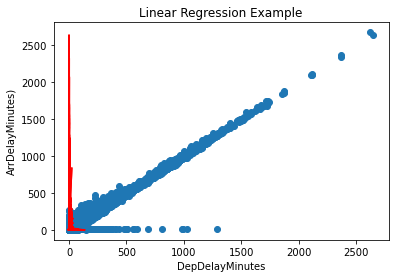

In [76]:
# Plotting the dataset points
plt.scatter(test["DepDelayMinutes"], test["ArrDelayMinutes"])

# Plotting a line that represents our linear regression model "straight line"
# preds are the results from the model --> they represent the model equation
plt.plot(X_test, preds, c="r")
# preds -> flipper length (prediction from test)
# X_test is the body_mass
plt.title("Linear Regression Example")
plt.xlabel("DepDelayMinutes")
plt.ylabel("ArrDelayMinutes)")

## Multi-linear Regression

In [18]:
df_3 = dataset[["DivAirportLandings","DepartureDelayGroups","DepDel15","DepDelay","DepDelayMinutes","Diverted","CRSDepTime", "WheelsOff", "WheelsOn","Distance","ArrDelayMinutes","DistanceGroup"]].copy()

In [22]:
# Handling the columns missing values:

DepartureDelayGroups_mean = round(df_3['DepartureDelayGroups'].mean())
DepDel15_mean = round(df_3['DepDel15'].mean())
DepDelay_mean = round(df_3['DepDelay'].mean())
DepDelayMinutes_mean = round(df_3['DepDelayMinutes'].mean())
WheelsOff_mean = round(df_3['WheelsOff'].mean())
WheelsOn_mean = round(df_3['WheelsOn'].mean())
ArrDelayMinutes_mean = round(df_3['ArrDelayMinutes'].mean())

In [23]:
# Replace NaN values with the mean:
df_3["DepartureDelayGroups"].fillna(DepartureDelayGroups_mean, inplace=True)
df_3["DepDel15"].fillna(DepDel15_mean, inplace=True)
df_3["DepDelay"].fillna(DepDelay_mean, inplace=True)
df_3["DepDelayMinutes"].fillna(DepDelayMinutes_mean, inplace=True)
df_3["WheelsOff"].fillna(WheelsOff_mean, inplace=True)
df_3["WheelsOn"].fillna(WheelsOn_mean, inplace=True)
df_3["ArrDelayMinutes"].fillna(ArrDelayMinutes_mean, inplace=True)

df_3.isnull().sum()

DivAirportLandings      0
DepartureDelayGroups    0
DepDel15                0
DepDelay                0
DepDelayMinutes         0
Diverted                0
CRSDepTime              0
WheelsOff               0
WheelsOn                0
Distance                0
ArrDelayMinutes         0
DistanceGroup           0
dtype: int64

In [24]:
df_3

,DivAirportLandings,DepartureDelayGroups,DepDel15,DepDelay,DepDelayMinutes,Diverted,CRSDepTime,WheelsOff,WheelsOn,Distance,ArrDelayMinutes,DistanceGroup
0,0,-1.0,0.0,-10.0,0.0,False,1133,1140.0,1220.0,212.0,0.0,1
1,0,-1.0,0.0,-4.0,0.0,False,732,744.0,839.0,295.0,0.0,2
2,0,-1.0,0.0,-15.0,0.0,False,1529,1535.0,1622.0,251.0,0.0,2
3,0,-1.0,0.0,-5.0,0.0,False,1435,1446.0,1543.0,376.0,0.0,2
4,0,0.0,0.0,0.0,0.0,False,1135,1154.0,1243.0,251.0,6.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
4078313,1,1.0,1.0,25.0,25.0,True,1949,2031.0,202.0,1167.0,16.0,5
4078314,0,2.0,1.0,44.0,44.0,False,1733,1357.0,1455.0,529.0,16.0,3
4078315,0,12.0,1.0,378.0,378.0,False,1700,2337.0,52.0,723.0,381.0,3
4078316,1,7.0,1.0,113.0,113.0,True,2129,2347.0,933.0,319.0,16.0,2


In [25]:
corr2 = df_3.corr()

corr2.style.background_gradient(cmap='coolwarm')

,DivAirportLandings,DepartureDelayGroups,DepDel15,DepDelay,DepDelayMinutes,Diverted,CRSDepTime,WheelsOff,WheelsOn,Distance,ArrDelayMinutes,DistanceGroup
DivAirportLandings,1.000000,0.015123,0.012803,0.011018,0.010795,0.440203,0.005303,0.007080,0.004191,0.001106,0.000210,0.001073
DepartureDelayGroups,0.015123,1.000000,0.749341,0.822824,0.809136,0.019650,0.144985,0.185131,0.052022,0.032447,0.774439,0.033190
DepDel15,0.012803,0.749341,1.000000,0.545631,0.526658,0.017376,0.179834,0.219817,0.095859,0.035311,0.481821,0.036063
DepDelay,0.011018,0.822824,0.545631,1.000000,0.997938,0.014961,0.099154,0.115630,0.023184,0.021824,0.972781,0.022216
DepDelayMinutes,0.010795,0.809136,0.526658,0.997938,1.000000,0.014518,0.093083,0.108118,0.017863,0.016313,0.975948,0.016697
Diverted,0.440203,0.019650,0.017376,0.014961,0.014518,1.000000,0.001864,0.004510,0.009596,0.013689,0.000206,0.013680
CRSDepTime,0.005303,0.144985,0.179834,0.099154,0.093083,0.001864,1.000000,0.899966,0.595981,-0.003996,0.083669,-0.005126
WheelsOff,0.007080,0.185131,0.219817,0.115630,0.108118,0.004510,0.899966,1.000000,0.661154,-0.026517,0.101625,-0.027800
WheelsOn,0.004191,0.052022,0.095859,0.023184,0.017863,0.009596,0.595981,0.661154,1.000000,0.011698,0.018974,0.014988
Distance,0.001106,0.032447,0.035311,0.021824,0.016313,0.013689,-0.003996,-0.026517,0.011698,1.000000,0.010795,0.986352


In [26]:
# ArrDelayMinutes, TaxiOut, WheelsOff, CRSDepTime
vars = [ "DepartureDelayGroups", "DepDel15", "DepDelay", "DepDelayMinutes"]

X = df_3[vars]
y = df_3.ArrDelayMinutes

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, train_size=0.75, random_state=2)

In [27]:
X_train_1.head()

,DepartureDelayGroups,DepDel15,DepDelay,DepDelayMinutes
3392087,0.0,0.0,9.0,9.0
3216195,-1.0,0.0,-3.0,0.0
1208624,-1.0,0.0,-5.0,0.0
3321815,-1.0,0.0,-4.0,0.0
3441273,12.0,1.0,217.0,217.0


In [28]:
y_train_1.head()

3392087      0.0
3216195      0.0
1208624      0.0
3321815      0.0
3441273    216.0
Name: ArrDelayMinutes, dtype: float64

In [29]:
y_train_1.info()

<class 'pandas.core.series.Series'>
Int64Index: 3058738 entries, 3392087 to 1924264
Series name: ArrDelayMinutes
Non-Null Count    Dtype  
--------------    -----  
3058738 non-null  float64
dtypes: float64(1)
memory usage: 46.7 MB


In [30]:
X_train_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3058738 entries, 3392087 to 1924264
Data columns (total 4 columns):
 #   Column                Dtype  
---  ------                -----  
 0   DepartureDelayGroups  float64
 1   DepDel15              float64
 2   DepDelay              float64
 3   DepDelayMinutes       float64
dtypes: float64(4)
memory usage: 116.7 MB


In [41]:
sc = StandardScaler()

# Note: We are scaling all the variables "Age and Salary" for improved performance 
# Note: we only scale continous numneric variables --> DONT scale discrete numbers 
# The scaling will be between 3 and -3 

X_train_1 = sc.fit_transform(X_train_1)
X_test_1 = sc.transform(X_test_1)

In [42]:
multi_lr = LinearRegression()

In [43]:
multi_lr.fit(X_train_1, y_train_1)

LinearRegression()

In [44]:
multi_lr.intercept_

15.808239214996513

In [45]:
multi_lr.coef_

array([-0.21099475, -2.10882301, -3.36543619, 54.52675038])

In [46]:
multi_predictions = multi_lr.predict(X_test_1)

In [47]:
r2_score(y_true=y_test_1, y_pred=multi_predictions)

0.9519467906372215

In [49]:
mean_absolute_error(y_true=y_test_1, y_pred=multi_predictions )

5.083968354645791

In [58]:
np.round(multi_lr.predict([[ 2.0, 1.0,37,37]]))

array([1906.])

## Random forest 

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [57]:
class_forest = RandomForestClassifier(n_estimators = 10, criterion = 'gini', random_state = 0)

class_forest.fit(X_train_1, y_train_1)
preds_class = class_forest.predict(X_test_1)

In [61]:
plot_confusion_matrix(X_test_1, y_test_1);

TypeError: plot_confusion_matrix() missing 1 required positional argument: 'y_true'

In [65]:
val_test = round(class_forest.score(X_test_1, y_test_1),2)*100

print(f'Test Set Accuracy: {val_test}%')

NameError: name 'val_train' is not defined

In [ ]:
plot_confusion_matrix(class_forest, X=X_test_1, y_true=y_test_1, cmap='Blues')